In [4]:
import clearml
import sklearn
import splitfolders
import torch
import os
import matplotlib.pyplot as plt
import skimage
import numpy as np
import pandas as pd
import rich

from torchinfo import summary
from rich.progress import Progress
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.svm import SVC
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix, classification_report
from clearml import Dataset, Task
from skimage.feature import local_binary_pattern, hog

In [5]:
%env CLEARML_WEB_HOST=https://app.clear.ml/
%env CLEARML_API_HOST=https://api.clear.ml
%env CLEARML_FILES_HOST=https://files.clear.ml
%env CLEARML_API_ACCESS_KEY=ZS6BVHQGC1N89QELVVW3EITSJBRKZS
%env CLEARML_API_SECRET_KEY=OmTm8v5yFGP17jRh0wzamCJQKfmL_0e-VPYo4vE4eG-6XIzs5Aa89UvDmQ4F9nOklBQ

env: CLEARML_WEB_HOST=https://app.clear.ml/
env: CLEARML_API_HOST=https://api.clear.ml
env: CLEARML_FILES_HOST=https://files.clear.ml
env: CLEARML_API_ACCESS_KEY=ZS6BVHQGC1N89QELVVW3EITSJBRKZS
env: CLEARML_API_SECRET_KEY=OmTm8v5yFGP17jRh0wzamCJQKfmL_0e-VPYo4vE4eG-6XIzs5Aa89UvDmQ4F9nOklBQ


# DATA PREPROCESSING AND VISUALIZATION

In [ ]:
!unzip -q student_24902037.zip

In [ ]:
# Set up correct directory structure. Train = 70%, Validation = 10%, Test = 20%

splitfolders.ratio(input=r'/content/student_24902037', output='output', seed=0, ratio=(0.7, 0.1, 0.2), shuffle=True)

Copying files: 5000 files [00:01, 4497.82 files/s]


In [ ]:
dataset = Dataset.create(dataset_project="A1", dataset_name="ImgData-v.1")
dataset.add_files(path=r"/content/output")
dataset.upload()
dataset.finalize()

ClearML results page: https://app.clear.ml/projects/dd1458c307614013ac2b6615cbdc05fb/experiments/7c63d55db4b0498d89ed916e42cce2cd/output/log
ClearML dataset page: https://app.clear.ml/datasets/simple/dd1458c307614013ac2b6615cbdc05fb/experiments/7c63d55db4b0498d89ed916e42cce2cd
Generating SHA2 hash for 5000 files


100%|██████████| 5000/5000 [00:00<00:00, 7741.95it/s]


Hash generation completed
Uploading dataset changes (5000 files compressed to 5.73 MiB) to https://files.clear.ml


█████████████████████████████████ 100% | 5.73/5.73 MB [00:00<00:00, 35.68MB/s]: 


File compression and upload completed: total size 5.73 MiB, 1 chunk(s) stored (average size 5.73 MiB)


True

In [6]:
dataset = Dataset.get(dataset_name="ImgData-v.1")
local_copy = dataset.get_local_copy()

                                            0% | 0.00/5.73 MB [00:00<?, ?MB/s]: /usr/local/lib/python3.12/dist-packages/tqdm/std.py:636: TqdmWarning: clamping frac to range [0, 1]
  full_bar = Bar(frac,
██████████████████████████████ 100% | 5.73/5.73 MB [00:00<-00:00, 1880.50MB/s]: 


ClearML Task: created new task id=9bb609f752d54d37b53ac16a36842497
ClearML results page: https://app.clear.ml/projects/6e3c9e5bed2e4f87bd9578ae19b14438/experiments/9bb609f752d54d37b53ac16a36842497/output/log


Could not fetch GPU stats: NVML Shared Library Not Found


Dimension of image: (45, 45)


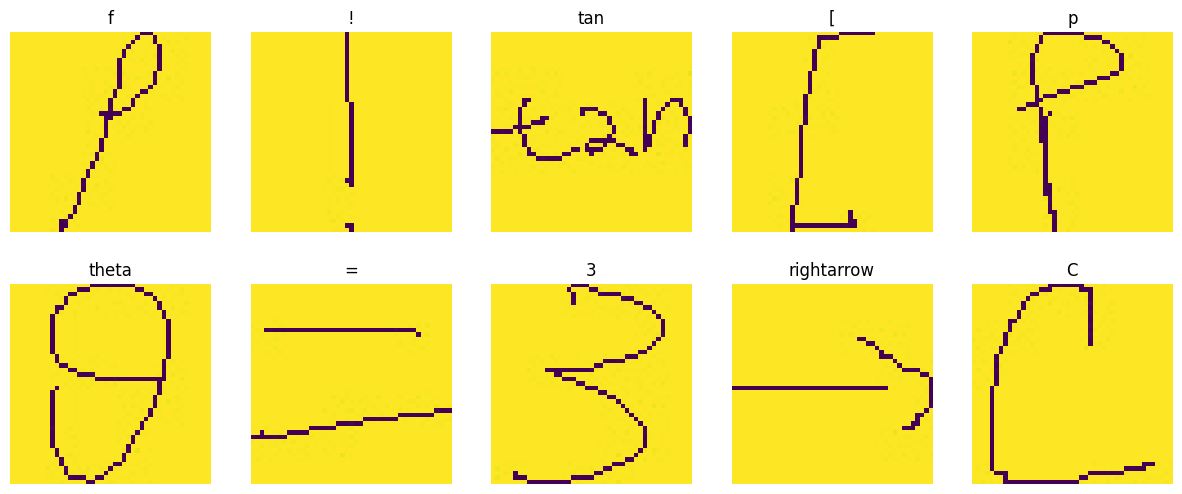

In [ ]:
# Examine sample image of each class

task = Task.init(project_name="A1",
                 task_name="Data Preprocessing and Visualization",
                 task_type=Task.TaskTypes.data_processing,
                 auto_connect_frameworks={'matplotlib': False})

logger = task.get_logger()
fig, ax = plt.subplots(nrows=2, ncols=5, figsize=(15, 6))
DATASET_PATH = os.path.join(local_copy, "train")

for i in range(len(os.listdir(DATASET_PATH))):
  class_path = os.path.join(DATASET_PATH, os.listdir(DATASET_PATH)[i])
  image = plt.imread(fname=os.path.join(class_path, os.listdir(class_path)[0]))
  ax[i // 5][i % 5].imshow(image)
  ax[i // 5][i % 5].axis("off")
  ax[i // 5][i % 5].set_title(str(os.listdir(DATASET_PATH)[i]))

logger.report_matplotlib_figure(title="Sample image of each class",
                                series="Grid",
                                figure=fig,
                                iteration=0)
logger.flush()
print(f'Dimension of image: {image.shape}')

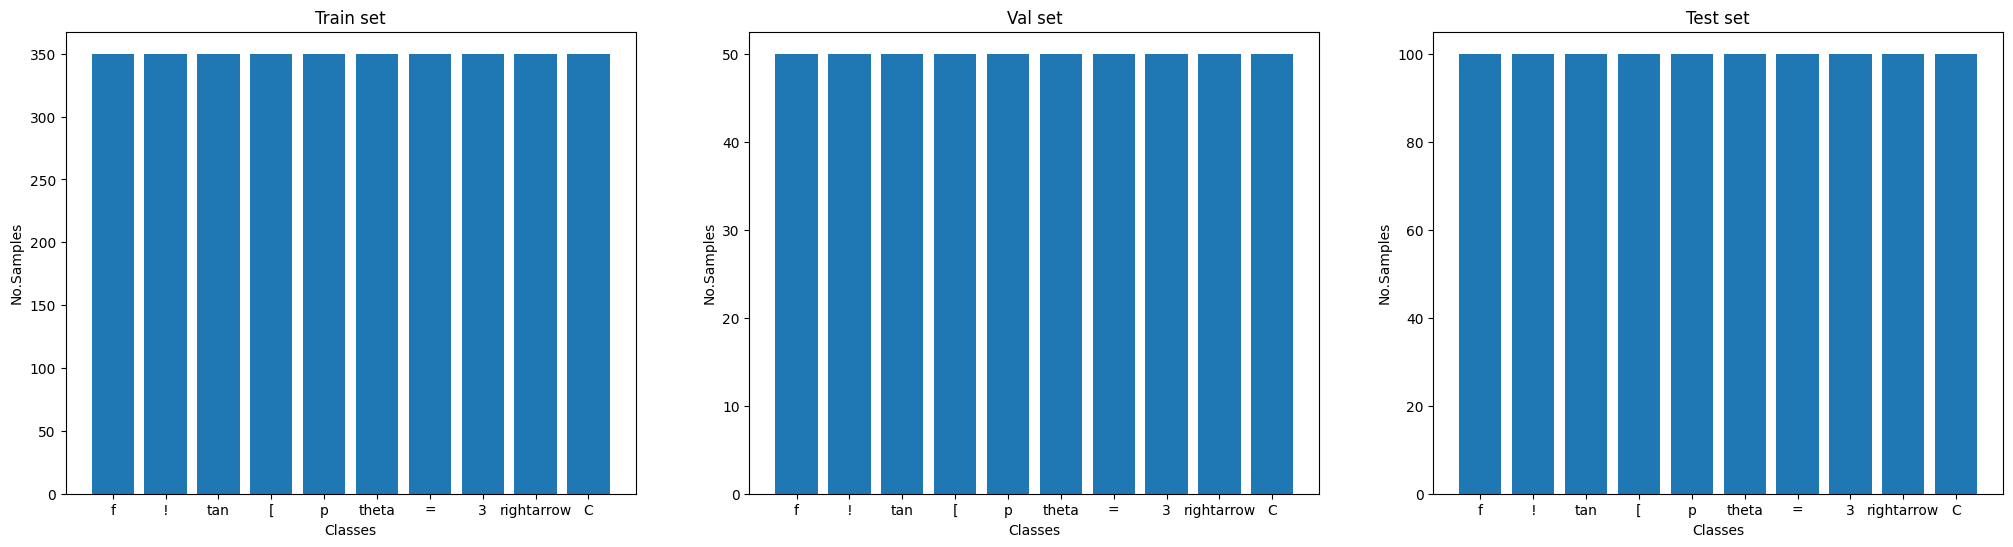

In [ ]:
# Check class distribution

def class_count(dataset: str) -> dict:
  result = {}
  DATASET_PATH = os.path.join(local_copy, dataset)

  for class_folder in os.listdir(DATASET_PATH):
    class_path = os.path.join(DATASET_PATH, class_folder)
    result[class_folder] = len(os.listdir(class_path))

  return result

train_class_count = class_count("train")
val_class_count = class_count("val")
test_class_count = class_count("test")

fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(25, 6))
ax[0].bar(train_class_count.keys(), train_class_count.values())
ax[1].bar(val_class_count.keys(), val_class_count.values())
ax[2].bar(test_class_count.keys(), test_class_count.values())

ax[0].set_title("Train set")
ax[1].set_title("Val set")
ax[2].set_title("Test set")

ax[0].set_xlabel("Classes")
ax[0].set_ylabel("No.Samples")
ax[1].set_xlabel("Classes")
ax[1].set_ylabel("No.Samples")
ax[2].set_xlabel("Classes")
ax[2].set_ylabel("No.Samples")

logger.report_matplotlib_figure(title="Class Distribution",
                                series="Bar chart",
                                iteration=0,
                                figure=fig)
logger.flush()
plt.show()

In [ ]:
logger.report_scalar(title="Dataset Counts", series="train", value=sum(train_class_count.values()), iteration=0)
logger.report_scalar(title="Dataset Counts", series="val", value=sum(val_class_count.values()), iteration=0)
logger.report_scalar(title="Dataset Counts", series="test", value=sum(test_class_count.values()), iteration=0)
task.close()

# FEATURE EXTRACTION

In [ ]:
# Mapping from string labels to numeric labels for training
task = Task.init(project_name="A1",
                 task_name="Feature Extraction",
                 task_type=Task.TaskTypes.data_processing)

logger = task.get_logger()

labels_map = {"!" : 0,
              "3" : 1,
              "=" : 2,
              "C" : 3,
              "[" : 4,
              "f" : 5,
              "p" : 6,
              "rightarrow" : 7,
              "tan" : 8,
              "theta" : 9}

def feature_extractor_factory(feature_function):
  def feature_extractor(dataset: str) -> tuple:
    DATASET_PATH = os.path.join(local_copy, dataset)
    labels = []
    feature_vector = []

    for class_folder in os.listdir(DATASET_PATH):
      class_path = os.path.join(DATASET_PATH, class_folder)
      for image in os.listdir(class_path):
        image_path = os.path.join(class_path, image)
        labels.append(labels_map[class_folder])  # Convert string label to numeric label for training model
        img = plt.imread(fname=image_path)

        # The only difference between the 3 features: HOG, LBP, and raw pixels are in how they process the image
        feature = feature_function(img)
        feature_vector.append(feature)

    return np.array(feature_vector), np.array(labels)

  return feature_extractor

# Helper functions
def raw_pixels(image: np.ndarray) -> np.ndarray:
  return image.flatten() / 255   # Normalize pixel values

def histogram_of_gradient(image: np.ndarray) -> np.ndarray:
  return hog(image, orientations=9, pixels_per_cell=(10, 10), cells_per_block=(2, 2), transform_sqrt=False, feature_vector=True, visualize=False, block_norm="L2-Hys")

def lbp(image: np.ndarray) -> np.ndarray:
  lbp = local_binary_pattern(image, P=8, R=1, method="uniform")
  hist, _ = np.histogram(lbp.ravel(), bins=np.arange(0, 11), range=(0, 10))
  hist = hist.astype("float")
  hist /= hist.sum()  # Normalize histogram
  return hist

# Create feature extractor functions
extract_raw_pixels = feature_extractor_factory(raw_pixels)
extract_hog = feature_extractor_factory(histogram_of_gradient)
extract_lbp = feature_extractor_factory(lbp)

In [ ]:
# Check dimension of each feature extractor

raw_pixels_feature = extract_raw_pixels(dataset="val")
hog_feature = extract_hog(dataset="val")
lbp_feature = extract_lbp(dataset="val")

print(f"Raw pixel feature dimension: {raw_pixels_feature[0].shape}")
print(f"HOG feature dimension: {hog_feature[0].shape}")
print(f"LBP feature dimension: {lbp_feature[0].shape}")

# Log raw pixel feature dimension
logger.report_scalar(title="Raw pixels", series="Dim1", value=raw_pixels_feature[0].shape[0], iteration=0)
logger.report_scalar(title="Raw pixels", series="Dim2", value=raw_pixels_feature[0].shape[1], iteration=0)

# Log HOG feature dimension
logger.report_scalar(title="HOG", series="Dim1", value=hog_feature[0].shape[0], iteration=0)
logger.report_scalar(title="HOG", series="Dim2", value=hog_feature[0].shape[1], iteration=0)

# Log LBP feature dimension
logger.report_scalar(title="LBP", series="Dim1", value=lbp_feature[0].shape[0], iteration=0)
logger.report_scalar(title="LBP", series="Dim2", value=lbp_feature[0].shape[1], iteration=0)

task.close()

Raw pixel feature dimension: (500, 2025)
HOG feature dimension: (500, 324)
LBP feature dimension: (500, 10)


# MODEL TRAINING

In [ ]:
# TRAIN
raw_pixels_feature_train = extract_raw_pixels(dataset="train")
hog_feature_train = extract_hog(dataset="train")
lbp_feature_train = extract_lbp(dataset="train")

# VAL
raw_pixels_feature_val = extract_raw_pixels(dataset="val")
hog_feature_val = extract_hog(dataset="val")
lbp_feature_val = extract_lbp(dataset="val")

# TEST
raw_pixels_feature_test = extract_raw_pixels(dataset="test")
hog_feature_test = extract_hog(dataset="test")
lbp_feature_test = extract_lbp(dataset="test")

In [ ]:
# Define helper functions for evaluation metrics

def get_report(y_true: np.ndarray, y_pred: np.ndarray, target_names=labels_map.keys()) -> pd.DataFrame:
  return pd.DataFrame(classification_report(y_true, y_pred, target_names=target_names, output_dict=True))

def get_confusion_matrix(y_true: np.ndarray, y_pred: np.ndarray, dataset: str, ax):
  cm = confusion_matrix(y_true=y_true, y_pred=y_pred, labels=range(10))
  display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(labels_map.keys()))
  display.plot(ax=ax)
  display.ax_.set_title(dataset)

In [ ]:
# Define helper functions for model building

def build_SVM(X_train: np.ndarray, y_train: np.ndarray, **kwargs) -> SVC:
  svc = SVC(**kwargs)
  svc.fit(X_train, y_train)
  return svc

def build_ANN(X_train: np.ndarray, y_train: np.ndarray, hidden_layer_1: int, hidden_layer_2: int, epochs: int = 50, lr: float = 0.001) -> tuple: # Return the trained ANN model and its loss over time
  # Define model architecture
  class ANN(nn.Module):
    def __init__(self, input_shape: int, output_shape: int, hidden_layer_1: int, hidden_layer_2: int):
      super().__init__()
      self.layers = nn.Sequential(nn.Linear(in_features=input_shape,
                                            out_features=hidden_layer_1,
                                            bias=True),
                                  nn.ReLU(),
                                  nn.Linear(in_features=hidden_layer_1,
                                            out_features=hidden_layer_2,
                                            bias=True),
                                  nn.ReLU(),
                                  nn.Linear(in_features=hidden_layer_2,
                                            out_features=output_shape,
                                            bias=True))

    def forward(self, x: torch.Tensor):
      return self.layers(x)

  # Set random seed for reproducibility
  RANDOM_SEED = 42
  torch.manual_seed(RANDOM_SEED)
  model = ANN(input_shape=X_train.shape[1], output_shape=10, hidden_layer_1=hidden_layer_1, hidden_layer_2=hidden_layer_2)

  X_train, y_train = torch.from_numpy(X_train).float(), torch.from_numpy(y_train)

  # Mini-batch gradient descent
  BATCH_SIZE = 32
  train_dataset = TensorDataset(X_train, y_train)
  train_dataloader = DataLoader(dataset=train_dataset, batch_size=BATCH_SIZE, shuffle=True)

  # Set up loss function and optimizer
  loss_function = nn.CrossEntropyLoss()
  optimizer = torch.optim.Adam(model.parameters(), lr=lr)
  loss_over_time = []

  # Training loop
  with Progress() as progress:
    epoch_counter = progress.add_task(description="[cyan]EPOCH", total=epochs)
    batch_counter = progress.add_task(description="[magenta]BATCH", total=len(train_dataloader))

    for epoch in range(epochs):
      progress.update(epoch_counter, advance=1)
      train_loss = 0

      for batch, (feature, label) in enumerate(train_dataloader):
        model.train()
        y_logits = model(feature)

        loss = loss_function(y_logits, label) # Calculate loss
        train_loss += loss.item() # Accumulate training loss of each batch

        optimizer.zero_grad()
        loss.backward() # Backpropagation
        optimizer.step()

        progress.update(batch_counter, advance=1)

      progress.reset(batch_counter)
      loss_over_time.append(train_loss / len(train_dataloader)) # Record loss per batch per epoch

  return model, loss_over_time

In [ ]:
# Define helper functions for model evaluation and experiment logging

def evaluate_model(model, X_train: np.ndarray, y_train: np.ndarray, X_val: np.ndarray, y_val: np.ndarray, X_test: np.ndarray, y_test: np.ndarray, loss_over_time: list = None) -> tuple:
  # Get predictions
  if isinstance(model, SVC):
    y_train_pred = model.predict(X_train)
    y_val_pred = model.predict(X_val)
    y_test_pred = model.predict(X_test)
  else:
    # Convert numpy to torch since model accepts tensor not numpy array
    X_train, y_train = torch.from_numpy(X_train).float(), torch.from_numpy(y_train)
    X_val, y_val = torch.from_numpy(X_val).float(), torch.from_numpy(y_val)
    X_test, y_test = torch.from_numpy(X_test).float(), torch.from_numpy(y_test)

    model.eval()
    with torch.inference_mode(): # Turn of gradient tracking since we are not training
      y_train_logits = model(X_train)
      y_train_pred_probs = torch.softmax(y_train_logits, dim=1)
      y_train_pred = torch.argmax(y_train_pred_probs, dim=1)

      y_val_logits = model(X_val)
      y_val_pred_probs = torch.softmax(y_val_logits, dim=1)
      y_val_pred = torch.argmax(y_val_pred_probs, dim=1)

      y_test_logits = model(X_test)
      y_test_pred_probs = torch.softmax(y_test_logits, dim=1)
      y_test_pred = torch.argmax(y_test_pred_probs, dim=1)

    y_train_pred, y_val_pred, y_test_pred = y_train_pred.numpy(), y_val_pred.numpy(), y_test_pred.numpy() # Convert from tensor -> numpy to get report and confusion matrix

  # Plot confusion matrix and loss curve
  if not(isinstance(model, SVC)):
    fig_loss, ax_loss = plt.subplots(nrows=1, ncols=1, figsize=(6, 5))
    ax_loss.plot(range(len(loss_over_time)), loss_over_time)
    ax_loss.set_title("Training Loss")
    ax_loss.set_xlabel("Epoch")
    ax_loss.set_ylabel("Loss")
    plt.tight_layout()
    plt.show()

  fig_cm, ax_cm = plt.subplots(nrows=3, ncols=1, figsize=(15, 17))
  get_confusion_matrix(y_train, y_train_pred, ax=ax_cm[0], dataset="Train")
  get_confusion_matrix(y_val, y_val_pred, ax=ax_cm[1], dataset="Val")
  get_confusion_matrix(y_test, y_test_pred, ax=ax_cm[2], dataset="Test")
  plt.tight_layout()
  plt.show()

  # Get performance report
  train_report = get_report(y_true=y_train, y_pred=y_train_pred)
  val_report = get_report(y_true=y_val, y_pred=y_val_pred)
  test_report = get_report(y_true=y_test, y_pred=y_test_pred)

  return train_report, val_report, test_report, fig_cm

def log_experiment(model, train_report: pd.DataFrame, val_report: pd.DataFrame, test_report: pd.DataFrame, confusion_matrix_figure, task_name: str, input_size: tuple = None, loss_over_time: list = None):
  task = Task.init(project_name="A1",
                   task_name=task_name,
                   task_type=Task.TaskTypes.training)
  logger = task.get_logger()

  logger.report_table(title="Performance Metrics",
                      series="Train set",
                      iteration=0,
                      table_plot=train_report)

  logger.report_table(title="Performance Metrics",
                      series="Val set",
                      iteration=0,
                      table_plot=val_report)

  logger.report_table(title="Performance Metrics",
                      series="Test set",
                      iteration=0,
                      table_plot=test_report)

  logger.report_matplotlib_figure(title="Confusion Matrices",
                                  series="Grid",
                                  figure=confusion_matrix_figure,
                                  iteration=0)

  logger.flush()

  if isinstance(model, SVC):
    task.connect(model.get_params()) # Log model hyperparameter
  else:
    # Log the loss curve and model architecture
    for epoch in range(len(loss_over_time)):
      logger.report_scalar(title="Loss Curve", series="Train", value=loss_over_time[epoch], iteration=epoch)

    logger.report_text(str(summary(model, input_size=input_size)))

  task.close()

## RAW PIXEL VALUES

In [ ]:
X_train, y_train = raw_pixels_feature_train
X_val, y_val = raw_pixels_feature_val
X_test, y_test = raw_pixels_feature_test

### SVM

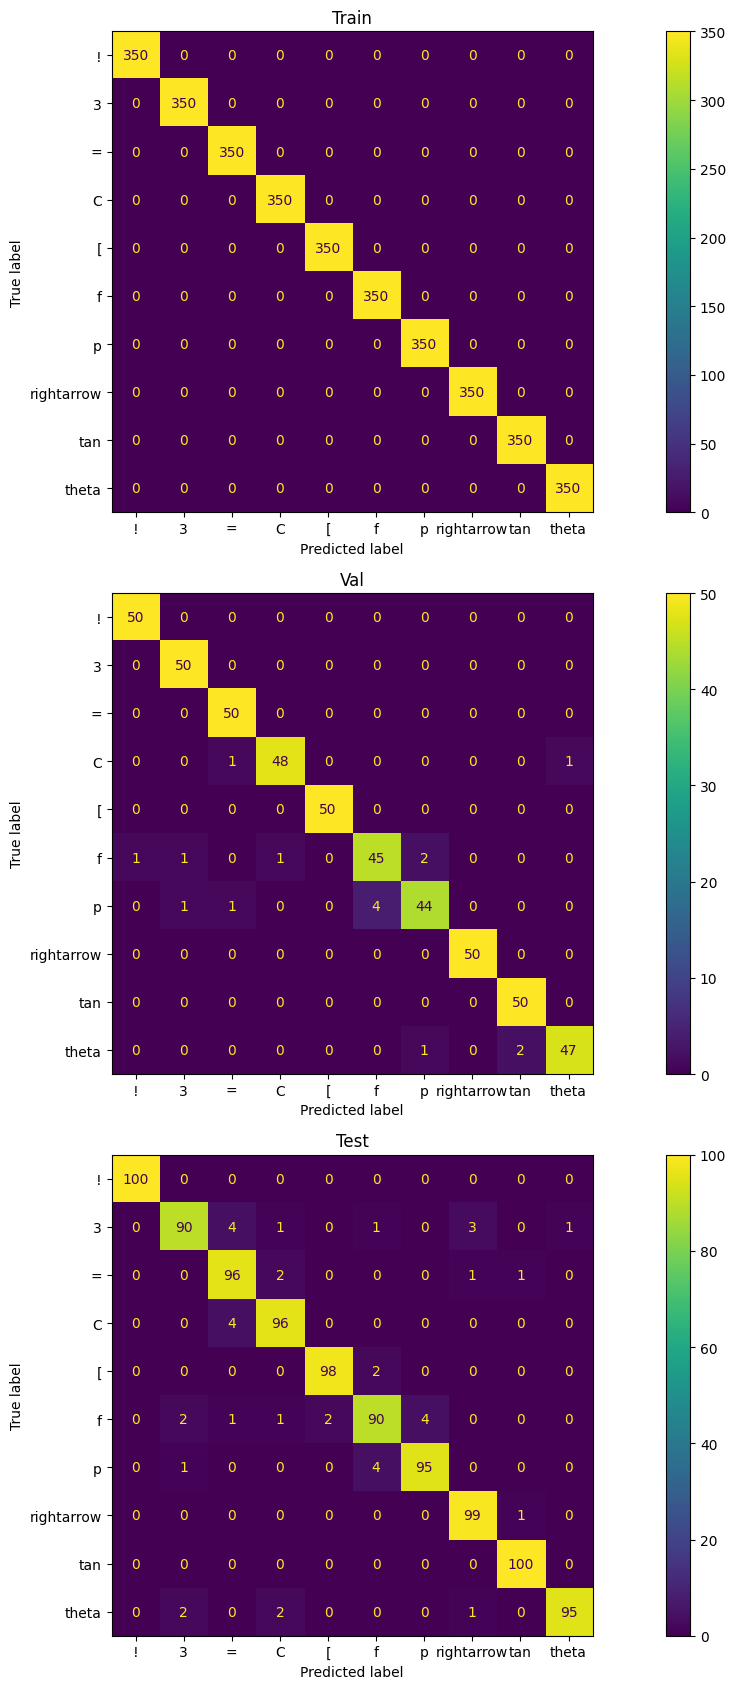

ClearML Task: created new task id=dcea04a5364e49fe9e12b188dffeb561
ClearML results page: https://app.clear.ml/projects/6e3c9e5bed2e4f87bd9578ae19b14438/experiments/dcea04a5364e49fe9e12b188dffeb561/output/log


Could not fetch GPU stats: NVML Shared Library Not Found


ClearML Monitor: GPU monitoring failed getting GPU reading, switching off GPU monitoring


In [ ]:
svm = build_SVM(X_train, y_train, C = 1.0, kernel="poly", degree=3, random_state=42)
train_report, val_report, test_report, cm_fig = evaluate_model(svm, X_train, y_train, X_val, y_val, X_test, y_test)
log_experiment(svm, train_report, val_report, test_report, cm_fig, "SVM-v3.0 (Raw Pixels)")

In [ ]:
train_report

,!,3,=,C,[,f,p,rightarrow,tan,theta,accuracy,macro avg,weighted avg
precision,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
recall,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
f1-score,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
support,350.0,350.0,350.0,350.0,350.0,350.0,350.0,350.0,350.0,350.0,1.0,3500.0,3500.0


In [ ]:
val_report

,!,3,=,C,[,f,p,rightarrow,tan,theta,accuracy,macro avg,weighted avg
precision,0.980392,0.961538,0.961538,0.979592,1.0,0.918367,0.936170,1.0,0.961538,0.979167,0.968,0.967830,0.967830
recall,1.000000,1.000000,1.000000,0.960000,1.0,0.900000,0.880000,1.0,1.000000,0.940000,0.968,0.968000,0.968000
f1-score,0.990099,0.980392,0.980392,0.969697,1.0,0.909091,0.907216,1.0,0.980392,0.959184,0.968,0.967646,0.967646
support,50.000000,50.000000,50.000000,50.000000,50.0,50.000000,50.000000,50.0,50.000000,50.000000,0.968,500.000000,500.000000


In [ ]:
test_report

,!,3,=,C,[,f,p,rightarrow,tan,theta,accuracy,macro avg,weighted avg
precision,1.0,0.947368,0.914286,0.941176,0.98,0.927835,0.959596,0.951923,0.980392,0.989583,0.959,0.959216,0.959216
recall,1.0,0.900000,0.960000,0.960000,0.98,0.900000,0.950000,0.990000,1.000000,0.950000,0.959,0.959000,0.959000
f1-score,1.0,0.923077,0.936585,0.950495,0.98,0.913706,0.954774,0.970588,0.990099,0.969388,0.959,0.958871,0.958871
support,100.0,100.000000,100.000000,100.000000,100.00,100.000000,100.000000,100.000000,100.000000,100.000000,0.959,1000.000000,1000.000000


### ANN

Output()

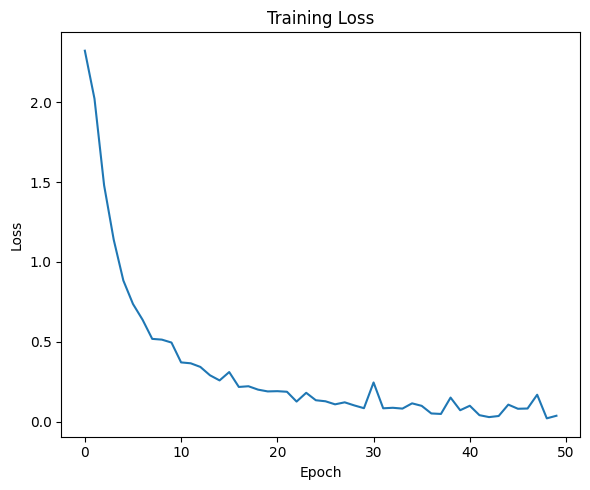

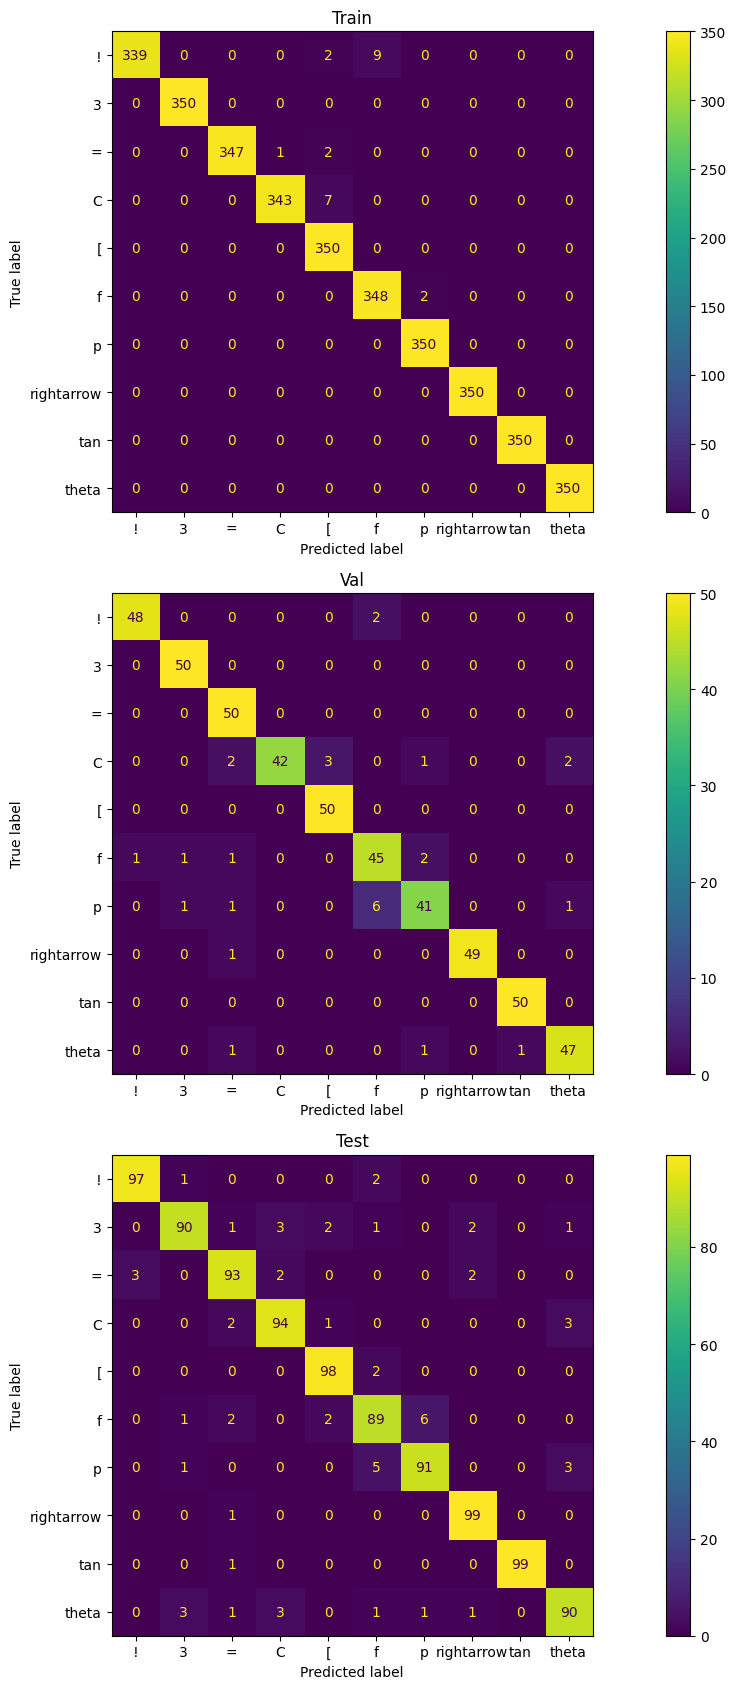

ClearML Task: created new task id=35903891adf34459a13959b7c4fc3a33
ClearML results page: https://app.clear.ml/projects/6e3c9e5bed2e4f87bd9578ae19b14438/experiments/35903891adf34459a13959b7c4fc3a33/output/log


Could not fetch GPU stats: NVML Shared Library Not Found


ClearML Monitor: GPU monitoring failed getting GPU reading, switching off GPU monitoring
Layer (type:depth-idx)                   Output Shape              Param #
ANN                                      [32, 10]                  --
├─Sequential: 1-1                        [32, 10]                  --
│    └─Linear: 2-1                       [32, 1024]                2,074,624
│    └─ReLU: 2-2                         [32, 1024]                --
│    └─Linear: 2-3                       [32, 256]                 262,400
│    └─ReLU: 2-4                         [32, 256]                 --
│    └─Linear: 2-5                       [32, 10]                  2,570
Total params: 2,339,594
Trainable params: 2,339,594
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 74.87
Input size (MB): 0.26
Forward/backward pass size (MB): 0.33
Params size (MB): 9.36
Estimated Total Size (MB): 9.95


In [ ]:
ann, loss_curve = build_ANN(X_train, y_train, hidden_layer_1=1024, hidden_layer_2=256)
train_report, val_report, test_report, cm_fig = evaluate_model(ann, X_train, y_train, X_val, y_val, X_test, y_test, loss_over_time=loss_curve)
log_experiment(ann, train_report, val_report, test_report, cm_fig, task_name="ANN-v1.0 (Raw Pixels)", input_size=(32, X_train.shape[1]), loss_over_time=loss_curve)

In [ ]:
train_report

,!,3,=,C,[,f,p,rightarrow,tan,theta,accuracy,macro avg,weighted avg
precision,1.000000,1.0,1.000000,0.997093,0.969529,0.974790,0.994318,1.0,1.0,1.0,0.993429,0.993573,0.993573
recall,0.968571,1.0,0.991429,0.980000,1.000000,0.994286,1.000000,1.0,1.0,1.0,0.993429,0.993429,0.993429
f1-score,0.984035,1.0,0.995696,0.988473,0.984529,0.984441,0.997151,1.0,1.0,1.0,0.993429,0.993432,0.993432
support,350.000000,350.0,350.000000,350.000000,350.000000,350.000000,350.000000,350.0,350.0,350.0,0.993429,3500.000000,3500.000000


In [ ]:
val_report

,!,3,=,C,[,f,p,rightarrow,tan,theta,accuracy,macro avg,weighted avg
precision,0.979592,0.961538,0.892857,1.000000,0.943396,0.849057,0.911111,1.000000,0.980392,0.94,0.944,0.945794,0.945794
recall,0.960000,1.000000,1.000000,0.840000,1.000000,0.900000,0.820000,0.980000,1.000000,0.94,0.944,0.944000,0.944000
f1-score,0.969697,0.980392,0.943396,0.913043,0.970874,0.873786,0.863158,0.989899,0.990099,0.94,0.944,0.943434,0.943434
support,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.00,0.944,500.000000,500.000000


In [ ]:
test_report

,!,3,=,C,[,f,p,rightarrow,tan,theta,accuracy,macro avg,weighted avg
precision,0.97,0.937500,0.920792,0.921569,0.951456,0.89,0.928571,0.951923,1.000000,0.927835,0.94,0.939965,0.939965
recall,0.97,0.900000,0.930000,0.940000,0.980000,0.89,0.910000,0.990000,0.990000,0.900000,0.94,0.940000,0.940000
f1-score,0.97,0.918367,0.925373,0.930693,0.965517,0.89,0.919192,0.970588,0.994975,0.913706,0.94,0.939841,0.939841
support,100.00,100.000000,100.000000,100.000000,100.000000,100.00,100.000000,100.000000,100.000000,100.000000,0.94,1000.000000,1000.000000


## HOG

In [ ]:
X_train, y_train = hog_feature_train
X_val, y_val = hog_feature_val
X_test, y_test = hog_feature_test

### SVM

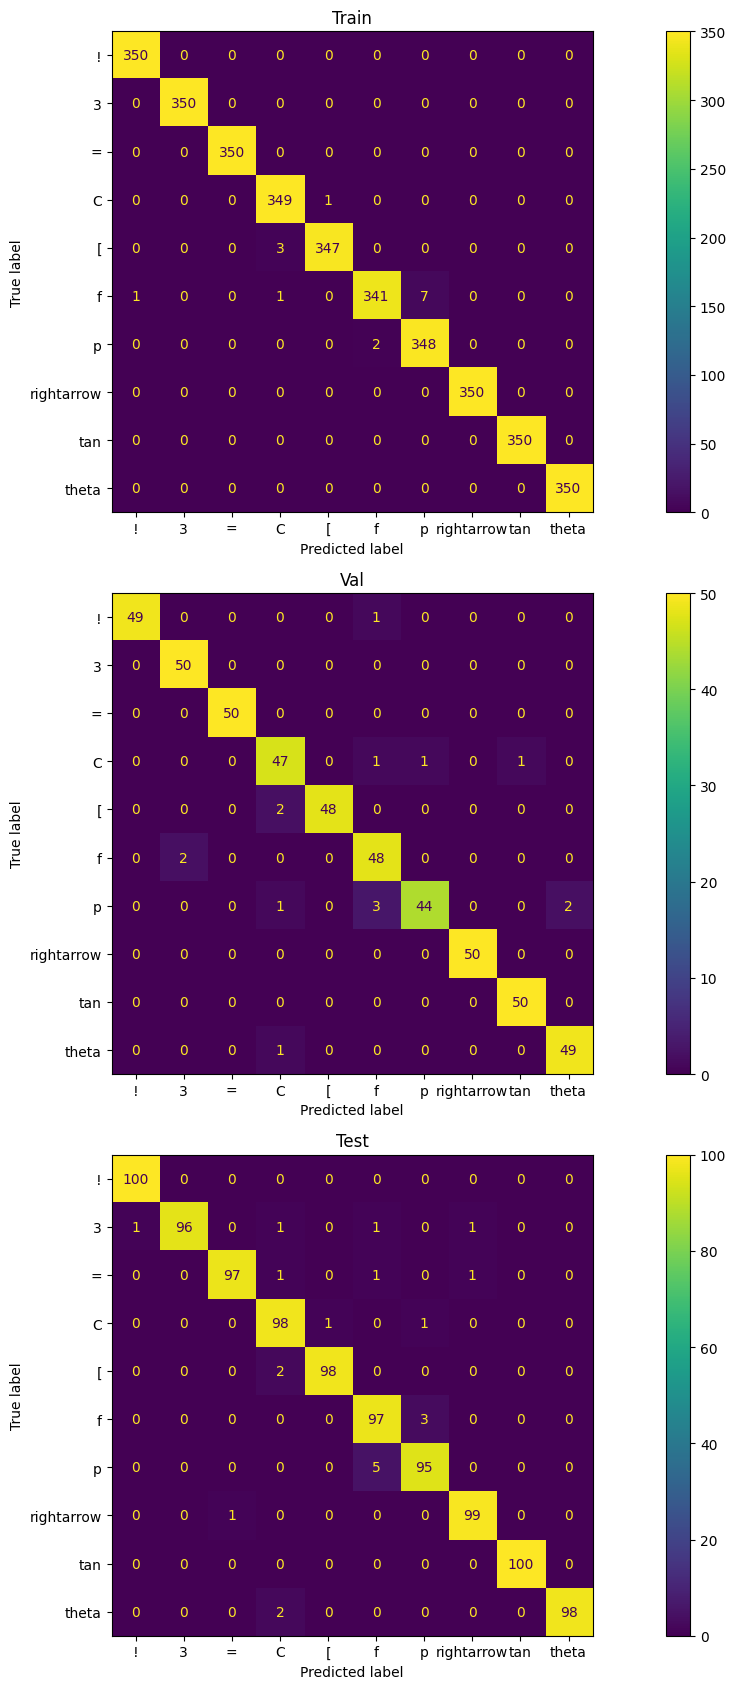

ClearML Task: created new task id=111b07805c1141d18b92791074469814
ClearML results page: https://app.clear.ml/projects/6e3c9e5bed2e4f87bd9578ae19b14438/experiments/111b07805c1141d18b92791074469814/output/log


Could not fetch GPU stats: NVML Shared Library Not Found


ClearML Monitor: GPU monitoring failed getting GPU reading, switching off GPU monitoring


In [ ]:
svm = build_SVM(X_train, y_train, C = 1.0, kernel="poly", degree=3, random_state=42)
train_report, val_report, test_report, cm_fig = evaluate_model(svm, X_train, y_train, X_val, y_val, X_test, y_test)
log_experiment(svm, train_report, val_report, test_report, cm_fig, "SVM-v3.0 (HOG)")

In [ ]:
train_report

,!,3,=,C,[,f,p,rightarrow,tan,theta,accuracy,macro avg,weighted avg
precision,0.997151,1.0,1.0,0.988669,0.997126,0.994169,0.980282,1.0,1.0,1.0,0.995714,0.995740,0.995740
recall,1.000000,1.0,1.0,0.997143,0.991429,0.974286,0.994286,1.0,1.0,1.0,0.995714,0.995714,0.995714
f1-score,0.998573,1.0,1.0,0.992888,0.994269,0.984127,0.987234,1.0,1.0,1.0,0.995714,0.995709,0.995709
support,350.000000,350.0,350.0,350.000000,350.000000,350.000000,350.000000,350.0,350.0,350.0,0.995714,3500.000000,3500.000000


In [ ]:
val_report

,!,3,=,C,[,f,p,rightarrow,tan,theta,accuracy,macro avg,weighted avg
precision,1.000000,0.961538,1.0,0.921569,1.000000,0.905660,0.977778,1.0,0.980392,0.960784,0.97,0.970772,0.970772
recall,0.980000,1.000000,1.0,0.940000,0.960000,0.960000,0.880000,1.0,1.000000,0.980000,0.97,0.970000,0.970000
f1-score,0.989899,0.980392,1.0,0.930693,0.979592,0.932039,0.926316,1.0,0.990099,0.970297,0.97,0.969933,0.969933
support,50.000000,50.000000,50.0,50.000000,50.000000,50.000000,50.000000,50.0,50.000000,50.000000,0.97,500.000000,500.000000


In [ ]:
test_report

,!,3,=,C,[,f,p,rightarrow,tan,theta,accuracy,macro avg,weighted avg
precision,0.990099,1.000000,0.989796,0.942308,0.989899,0.932692,0.959596,0.980198,1.0,1.000000,0.978,0.978459,0.978459
recall,1.000000,0.960000,0.970000,0.980000,0.980000,0.970000,0.950000,0.990000,1.0,0.980000,0.978,0.978000,0.978000
f1-score,0.995025,0.979592,0.979798,0.960784,0.984925,0.950980,0.954774,0.985075,1.0,0.989899,0.978,0.978085,0.978085
support,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.0,100.000000,0.978,1000.000000,1000.000000


### ANN

Output()

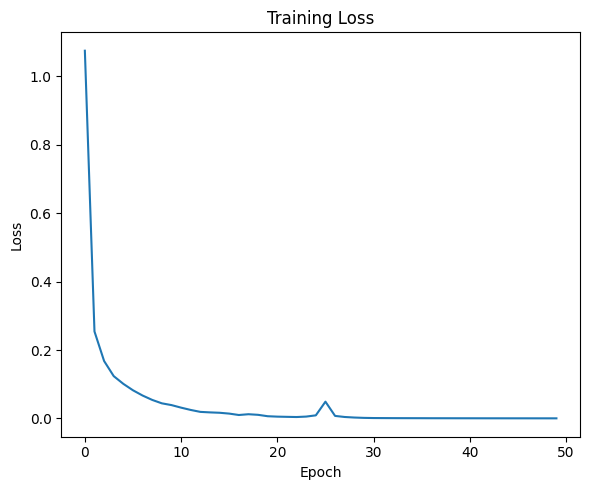

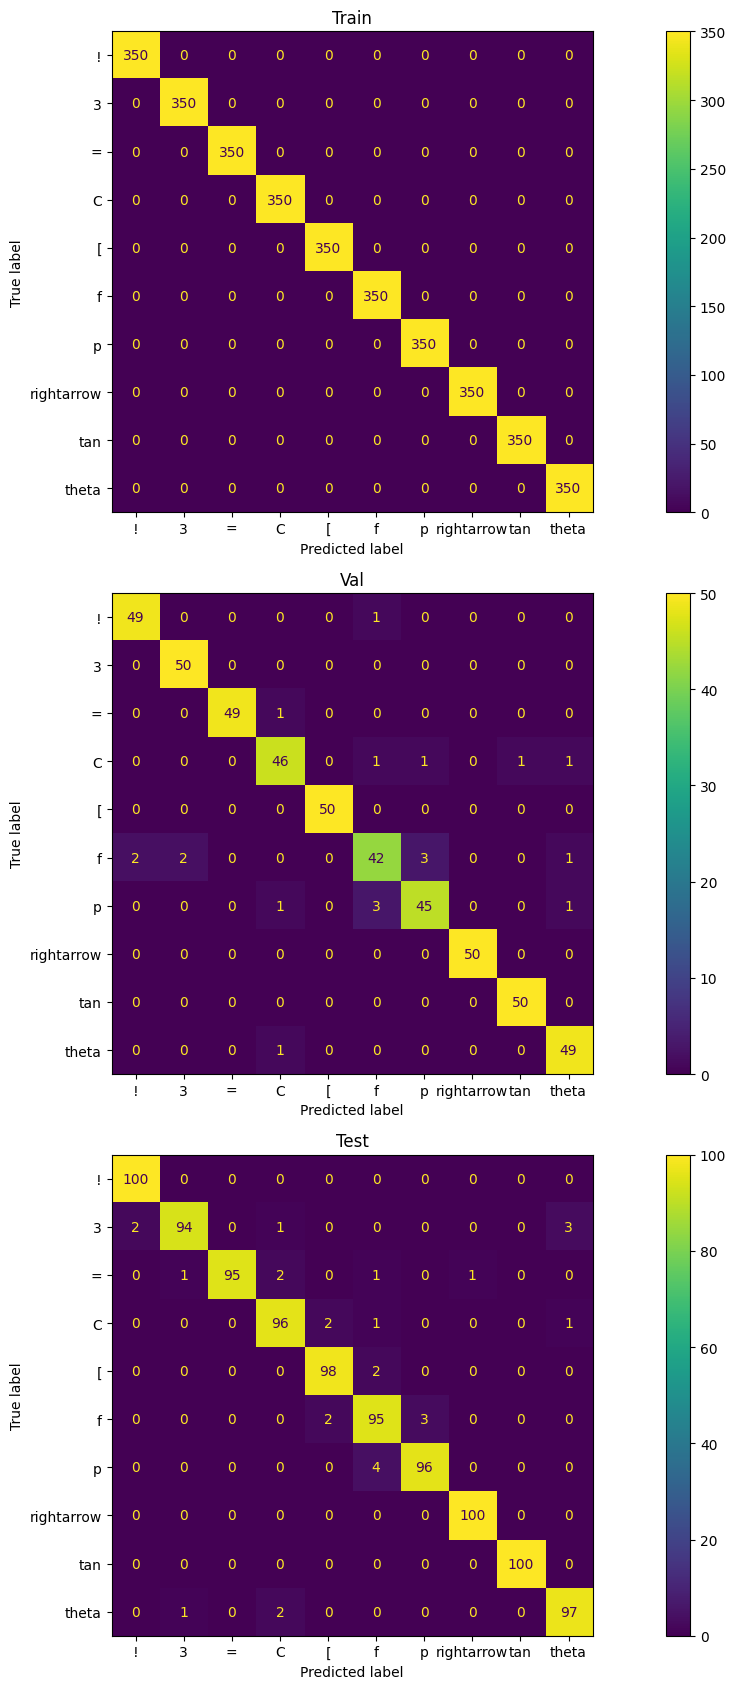

ClearML Task: created new task id=db2e82d7093645d6b5afff7ea73969c5
ClearML results page: https://app.clear.ml/projects/6e3c9e5bed2e4f87bd9578ae19b14438/experiments/db2e82d7093645d6b5afff7ea73969c5/output/log


Could not fetch GPU stats: NVML Shared Library Not Found


ClearML Monitor: GPU monitoring failed getting GPU reading, switching off GPU monitoring
Layer (type:depth-idx)                   Output Shape              Param #
ANN                                      [32, 10]                  --
├─Sequential: 1-1                        [32, 10]                  --
│    └─Linear: 2-1                       [32, 256]                 83,200
│    └─ReLU: 2-2                         [32, 256]                 --
│    └─Linear: 2-3                       [32, 128]                 32,896
│    └─ReLU: 2-4                         [32, 128]                 --
│    └─Linear: 2-5                       [32, 10]                  1,290
Total params: 117,386
Trainable params: 117,386
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 3.76
Input size (MB): 0.04
Forward/backward pass size (MB): 0.10
Params size (MB): 0.47
Estimated Total Size (MB): 0.61


In [ ]:
ann, loss_curve = build_ANN(X_train, y_train, hidden_layer_1=256, hidden_layer_2=128)
train_report, val_report, test_report, cm_fig = evaluate_model(ann, X_train, y_train, X_val, y_val, X_test, y_test, loss_over_time=loss_curve)
log_experiment(ann, train_report, val_report, test_report, cm_fig, task_name="ANN-v1.0 (HOG)", input_size=(32, X_train.shape[1]), loss_over_time=loss_curve)

In [ ]:
train_report

,!,3,=,C,[,f,p,rightarrow,tan,theta,accuracy,macro avg,weighted avg
precision,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
recall,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
f1-score,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
support,350.0,350.0,350.0,350.0,350.0,350.0,350.0,350.0,350.0,350.0,1.0,3500.0,3500.0


In [ ]:
val_report

,!,3,=,C,[,f,p,rightarrow,tan,theta,accuracy,macro avg,weighted avg
precision,0.960784,0.961538,1.000000,0.938776,1.0,0.893617,0.918367,1.0,0.980392,0.942308,0.96,0.959578,0.959578
recall,0.980000,1.000000,0.980000,0.920000,1.0,0.840000,0.900000,1.0,1.000000,0.980000,0.96,0.960000,0.960000
f1-score,0.970297,0.980392,0.989899,0.929293,1.0,0.865979,0.909091,1.0,0.990099,0.960784,0.96,0.959583,0.959583
support,50.000000,50.000000,50.000000,50.000000,50.0,50.000000,50.000000,50.0,50.000000,50.000000,0.96,500.000000,500.000000


In [ ]:
test_report

,!,3,=,C,[,f,p,rightarrow,tan,theta,accuracy,macro avg,weighted avg
precision,0.980392,0.979167,1.000000,0.950495,0.960784,0.922330,0.969697,0.990099,1.0,0.960396,0.971,0.971336,0.971336
recall,1.000000,0.940000,0.950000,0.960000,0.980000,0.950000,0.960000,1.000000,1.0,0.970000,0.971,0.971000,0.971000
f1-score,0.990099,0.959184,0.974359,0.955224,0.970297,0.935961,0.964824,0.995025,1.0,0.965174,0.971,0.971015,0.971015
support,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.0,100.000000,0.971,1000.000000,1000.000000


## LBP

In [ ]:
X_train, y_train = lbp_feature_train
X_val, y_val = lbp_feature_val
X_test, y_test = lbp_feature_test

### SVM

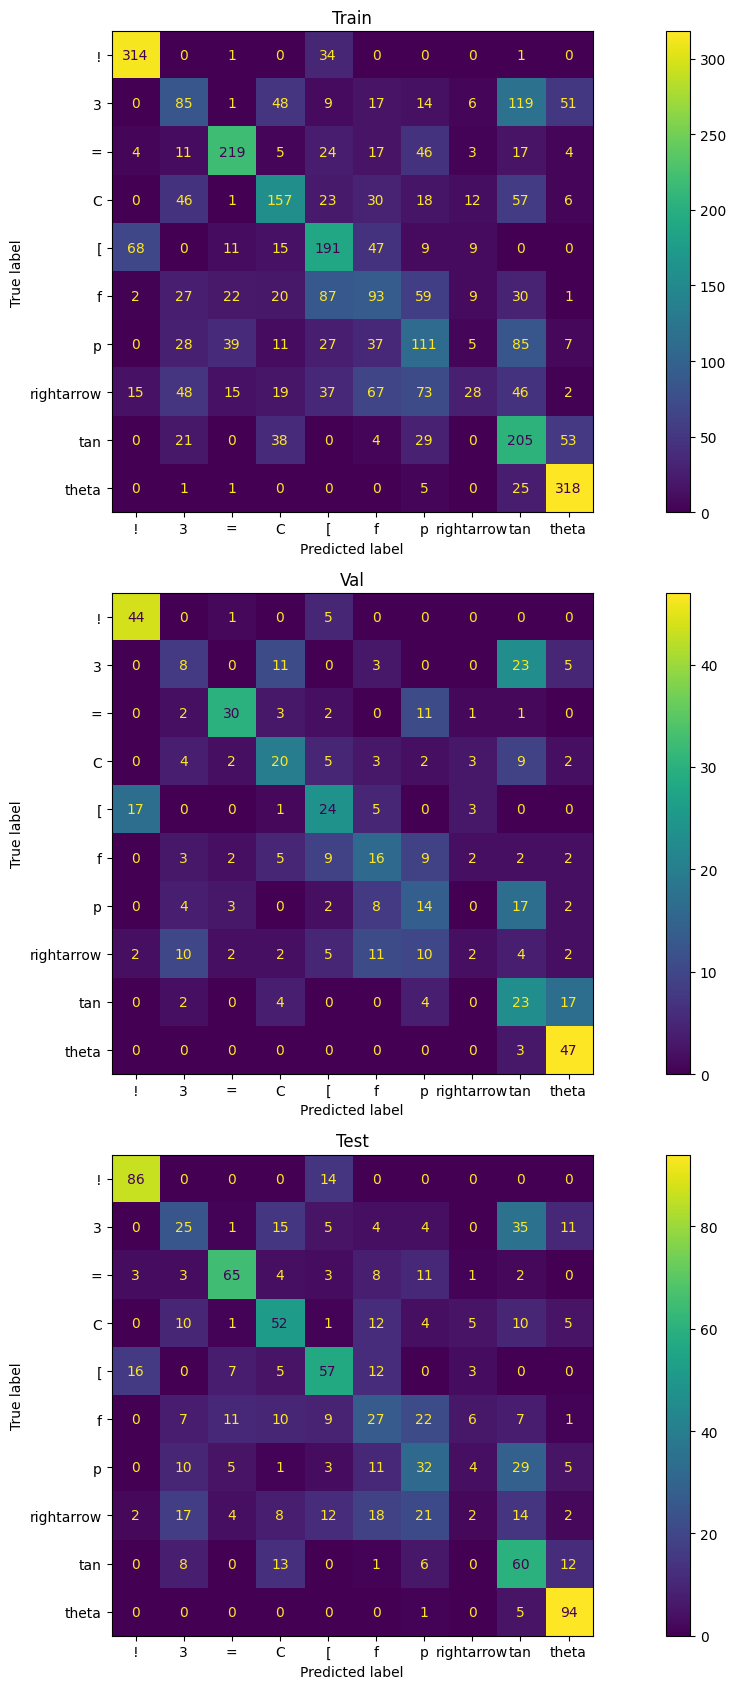

ClearML Task: created new task id=706227ca07a34871ade5bcc45601e6e3
ClearML results page: https://app.clear.ml/projects/6e3c9e5bed2e4f87bd9578ae19b14438/experiments/706227ca07a34871ade5bcc45601e6e3/output/log


Could not fetch GPU stats: NVML Shared Library Not Found


ClearML Monitor: GPU monitoring failed getting GPU reading, switching off GPU monitoring


In [ ]:
svm = build_SVM(X_train, y_train, C = 1.0, kernel="poly", degree=3, random_state=42)
train_report, val_report, test_report, cm_fig = evaluate_model(svm, X_train, y_train, X_val, y_val, X_test, y_test)
log_experiment(svm, train_report, val_report, test_report, cm_fig, "SVM-v2.0 (LBP)")

In [ ]:
train_report

,!,3,=,C,[,f,p,rightarrow,tan,theta,accuracy,macro avg,weighted avg
precision,0.779156,0.318352,0.706452,0.501597,0.442130,0.298077,0.304945,0.388889,0.350427,0.719457,0.491714,0.480948,0.480948
recall,0.897143,0.242857,0.625714,0.448571,0.545714,0.265714,0.317143,0.080000,0.585714,0.908571,0.491714,0.491714,0.491714
f1-score,0.833997,0.275527,0.663636,0.473605,0.488491,0.280967,0.310924,0.132701,0.438503,0.803030,0.491714,0.470138,0.470138
support,350.000000,350.000000,350.000000,350.000000,350.000000,350.000000,350.000000,350.000000,350.000000,350.000000,0.491714,3500.000000,3500.000000


In [ ]:
val_report

,!,3,=,C,[,f,p,rightarrow,tan,theta,accuracy,macro avg,weighted avg
precision,0.698413,0.242424,0.750000,0.434783,0.461538,0.347826,0.28,0.181818,0.280488,0.610390,0.456,0.428768,0.428768
recall,0.880000,0.160000,0.600000,0.400000,0.480000,0.320000,0.28,0.040000,0.460000,0.940000,0.456,0.456000,0.456000
f1-score,0.778761,0.192771,0.666667,0.416667,0.470588,0.333333,0.28,0.065574,0.348485,0.740157,0.456,0.429300,0.429300
support,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.00,50.000000,50.000000,50.000000,0.456,500.000000,500.000000


In [ ]:
test_report

,!,3,=,C,[,f,p,rightarrow,tan,theta,accuracy,macro avg,weighted avg
precision,0.803738,0.312500,0.691489,0.481481,0.548077,0.290323,0.316832,0.095238,0.370370,0.723077,0.5,0.463313,0.463313
recall,0.860000,0.250000,0.650000,0.520000,0.570000,0.270000,0.320000,0.020000,0.600000,0.940000,0.5,0.500000,0.500000
f1-score,0.830918,0.277778,0.670103,0.500000,0.558824,0.279793,0.318408,0.033058,0.458015,0.817391,0.5,0.474429,0.474429
support,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,0.5,1000.000000,1000.000000


### ANN

Output()

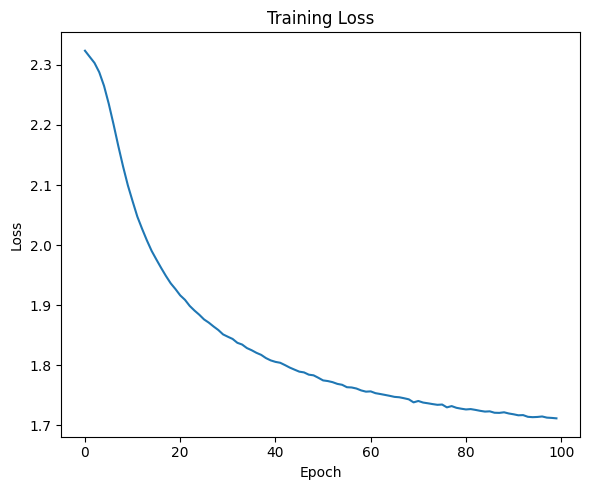

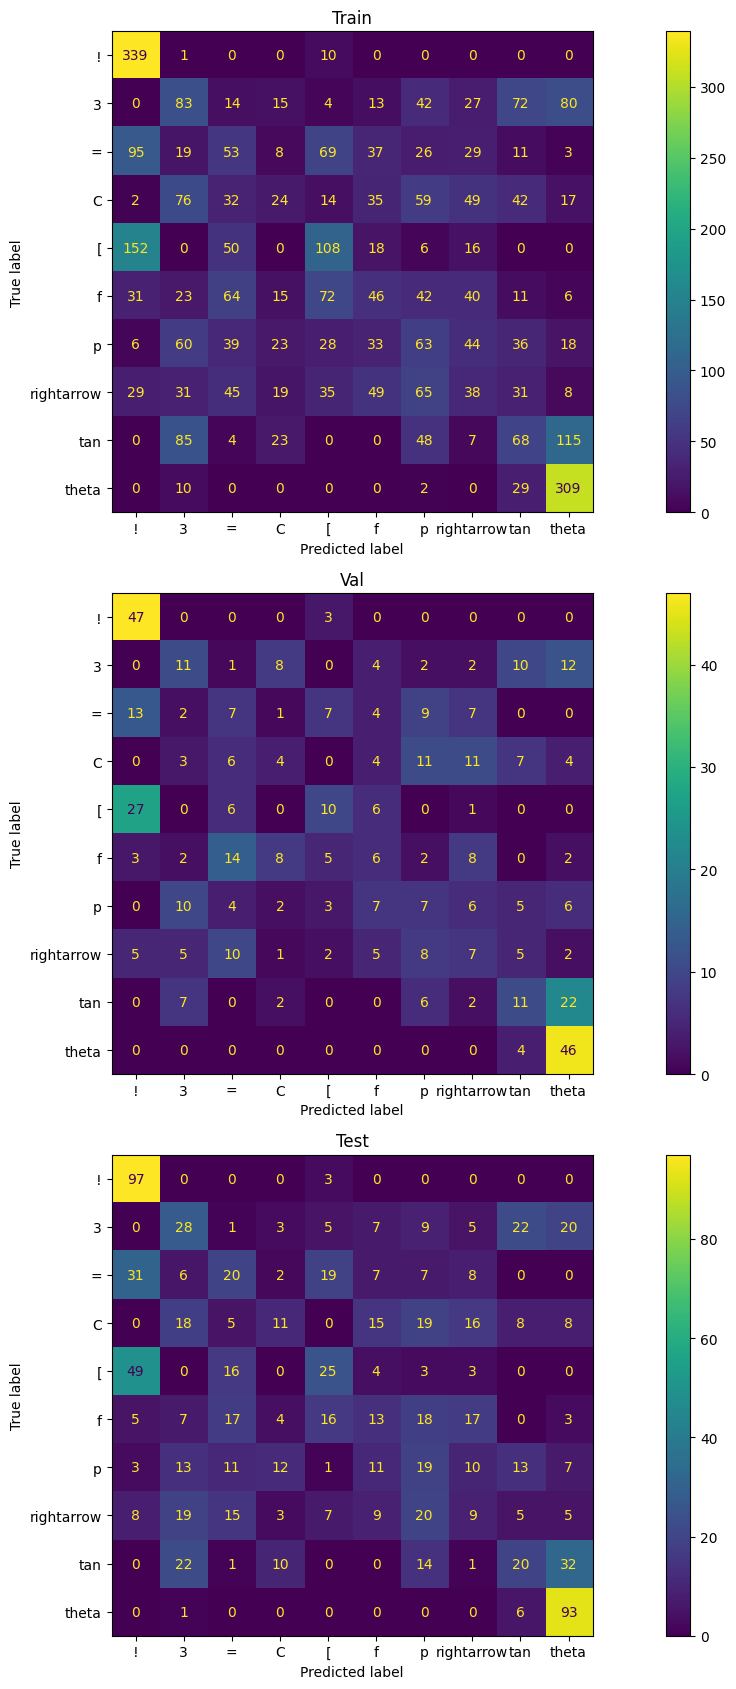

ClearML Task: created new task id=bfac3ae040784cdd94434fa7c0bfa540
ClearML results page: https://app.clear.ml/projects/6e3c9e5bed2e4f87bd9578ae19b14438/experiments/bfac3ae040784cdd94434fa7c0bfa540/output/log


Could not fetch GPU stats: NVML Shared Library Not Found


ClearML Monitor: GPU monitoring failed getting GPU reading, switching off GPU monitoring
Layer (type:depth-idx)                   Output Shape              Param #
ANN                                      [32, 10]                  --
├─Sequential: 1-1                        [32, 10]                  --
│    └─Linear: 2-1                       [32, 8]                   88
│    └─ReLU: 2-2                         [32, 8]                   --
│    └─Linear: 2-3                       [32, 4]                   36
│    └─ReLU: 2-4                         [32, 4]                   --
│    └─Linear: 2-5                       [32, 10]                  50
Total params: 174
Trainable params: 174
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.01
Input size (MB): 0.00
Forward/backward pass size (MB): 0.01
Params size (MB): 0.00
Estimated Total Size (MB): 0.01


In [ ]:
ann, loss_curve = build_ANN(X_train, y_train, hidden_layer_1=8, hidden_layer_2=4, epochs=100)
train_report, val_report, test_report, cm_fig = evaluate_model(ann, X_train, y_train, X_val, y_val, X_test, y_test, loss_over_time=loss_curve)
log_experiment(ann, train_report, val_report, test_report, cm_fig, task_name="ANN-v1.0 (LBP)", input_size=(32, X_train.shape[1]), loss_over_time=loss_curve)

In [ ]:
train_report

,!,3,=,C,[,f,p,rightarrow,tan,theta,accuracy,macro avg,weighted avg
precision,0.518349,0.213918,0.176080,0.188976,0.317647,0.199134,0.178470,0.152000,0.226667,0.555755,0.323143,0.272700,0.272700
recall,0.968571,0.237143,0.151429,0.068571,0.308571,0.131429,0.180000,0.108571,0.194286,0.882857,0.323143,0.323143,0.323143
f1-score,0.675299,0.224932,0.162826,0.100629,0.313043,0.158348,0.179232,0.126667,0.209231,0.682119,0.323143,0.283233,0.283233
support,350.000000,350.000000,350.000000,350.000000,350.000000,350.000000,350.000000,350.000000,350.000000,350.000000,0.323143,3500.000000,3500.000000


In [ ]:
val_report

,!,3,=,C,[,f,p,rightarrow,tan,theta,accuracy,macro avg,weighted avg
precision,0.494737,0.275000,0.145833,0.153846,0.333333,0.166667,0.155556,0.159091,0.261905,0.489362,0.312,0.263533,0.263533
recall,0.940000,0.220000,0.140000,0.080000,0.200000,0.120000,0.140000,0.140000,0.220000,0.920000,0.312,0.312000,0.312000
f1-score,0.648276,0.244444,0.142857,0.105263,0.250000,0.139535,0.147368,0.148936,0.239130,0.638889,0.312,0.270470,0.270470
support,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,0.312,500.000000,500.000000


In [ ]:
test_report

,!,3,=,C,[,f,p,rightarrow,tan,theta,accuracy,macro avg,weighted avg
precision,0.502591,0.245614,0.232558,0.244444,0.328947,0.196970,0.174312,0.130435,0.270270,0.553571,0.335,0.287971,0.287971
recall,0.970000,0.280000,0.200000,0.110000,0.250000,0.130000,0.190000,0.090000,0.200000,0.930000,0.335,0.335000,0.335000
f1-score,0.662116,0.261682,0.215054,0.151724,0.284091,0.156627,0.181818,0.106509,0.229885,0.694030,0.335,0.294354,0.294354
support,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,0.335,1000.000000,1000.000000
